이 파일은 로그 저장 방법 및 노드, 프롬포트가 수정된 버전입니다 \
로그를 chat_logs에 저정합니다. 

In [1]:
import os
import logging
from logging.handlers import RotatingFileHandler
import json
from pymongo import MongoClient
from datetime import datetime
from dotenv import load_dotenv
import pandas as pd
from typing import Literal, TypedDict, List
from pydantic import BaseModel, Field
from langchain_upstage import ChatUpstage
from langchain.schema import Document
from langchain_community.retrievers import BM25Retriever
from langchain_chroma import Chroma
from langchain_upstage import UpstageEmbeddings
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langchain.retrievers import EnsembleRetriever
from langgraph.graph import StateGraph, START, END
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.retrievers import ContextualCompressionRetriever
from langchain.text_splitter import RecursiveCharacterTextSplitter

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 환경 변수 로드
load_dotenv()

# 로그 저장 디렉토리 설정
LOG_DIR = "chat_logs"
os.makedirs(LOG_DIR, exist_ok=True)

log_formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')

# 1. 콘솔 핸들러 (기존과 동일, INFO 레벨)
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)
console_handler.setFormatter(log_formatter)

# 2. TXT 파일 핸들러 (에러 및 심각한 오류만 기록)

# 중간에 에러가 나도 기록하기 위함
txt_log_path = os.path.join(LOG_DIR, "runtime_errors.txt")

# 10MB 크기, 3개 파일 유지
file_handler = RotatingFileHandler(txt_log_path, maxBytes=10*1024*1024, backupCount=3, encoding='utf-8')
file_handler.setLevel(logging.ERROR) # ERROR 레벨 이상만 파일에 기록
file_handler.setFormatter(log_formatter)

# 3. 로거 설정
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO) # 로거의 기본 레벨은 INFO
logger.addHandler(console_handler) # 콘솔 핸들러 추가
logger.addHandler(file_handler)    # 파일 핸들러 추가

# MongoDB 클라이언트 설정
MONGO_IP = os.getenv("MONGO_IP")
MONGO_PORT = int(os.getenv("MONGO_PORT"))
MONGO_USER = os.getenv("MONGO_USER")
MONGO_PASSWORD = os.getenv("MONGO_PASSWORD")

# 연결 URI 생성
mongo_uri = f"mongodb://{MONGO_USER}:{MONGO_PASSWORD}@{MONGO_IP}:{MONGO_PORT}/?authSource=admin"
client = MongoClient(mongo_uri)

# 사용할 데이터베이스와 컬렉션 지정
db = client['chatbot_db']
collection = db['chat_logs']

In [3]:
#----1. 모델 정의----
model = ChatUpstage(model_name='solar-pro2', temperature=0)

In [4]:
#----2. State 정의----
class State(TypedDict):
    session_id: str
    conversation_count: int
    default_count: int
    input_msg: str
    initial_translated: str #Eng #rewrite 하면 여기로 저장됨
    route: str
    source: str
    documents: List[str]
    generation: str
    final_translated: str #Persian
    log_steps: List[dict] #누적된 로그를 담을 state

In [8]:
#----3. RAG 설정 (미리 로드)----
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Chroma DB 경로
persist_directory = "./chroma_db"

docs = []
data_folder = 'data'

for file_name in os.listdir(data_folder):
    if not file_name.lower().endswith(('.xlsx', '.xls')):
        continue

    file_path = os.path.join(data_folder, file_name)
    df = pd.read_excel(file_path)

    title_column = None
    if 'big_title_eng' in df.columns:
        title_column = 'big_title_eng'
    elif 'big_title_ara' in df.columns:
        title_column = 'big_title_ara'

    for index, row in df.iterrows():
        content = f"질문: {row.get('Question_ENG', '')}\n\n답변: {row.get('Answer_ENG', '')}"
        metadata = {
            "source": row.get('URL_ENG', ''),
            "row_number": index + 1
        }
        if title_column:
            metadata["category"] = row.get(title_column, '')

        docs.append(Document(page_content=content, metadata=metadata))
print(f"총 {len(docs)}개의 문서를 로드했습니다.")


# Chroma DB 존재 여부 확인 및 처리 
if os.path.exists(persist_directory) and len(os.listdir(persist_directory)) > 0:
    print("기존 Chroma DB 로드")
    chroma_db = Chroma(
        persist_directory=persist_directory,
        embedding_function=UpstageEmbeddings(model="solar-embedding-1-large")
    )
else:
    print("새로운 Chroma DB 생성 및 저장")
    embeddings = UpstageEmbeddings(model="solar-embedding-1-large")
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
    split_docs = text_splitter.split_documents(docs)
    print(f"청크 후 문서 개수: {len(split_docs)}")

    chroma_db = Chroma.from_documents(
        documents=split_docs,
        embedding=embeddings,
        persist_directory=persist_directory
    )

# Retriever 설정
chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 10})
bm25_retriever = BM25Retriever.from_documents(docs)
ensemble_retriever = EnsembleRetriever(
    retrievers=[chroma_retriever, bm25_retriever],
    weights=[0.5, 0.5]
)

# Re-ranking
llm_compressor = ChatUpstage(model_name='solar-pro2', temperature=0)
compressor = LLMChainExtractor.from_llm(llm_compressor)

compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=ensemble_retriever
)
print("RAG 설정 완료.")

총 2178개의 문서를 로드했습니다.
새로운 Chroma DB 생성 및 저장
청크 후 문서 개수: 14172


InternalError: Error updating collection: Database error: error returned from database: (code: 1032) attempt to write a readonly database

In [ ]:
def serialize_state(obj):
    if isinstance(obj, Document):
        return {
            "id": obj.id,
            "metadata": obj.metadata,
            "page_content": obj.page_content
        }
    elif isinstance(obj, list):
        return [serialize_state(o) for o in obj]
    elif isinstance(obj, dict):
        return {k: serialize_state(v) for k, v in obj.items()}
    return obj

In [7]:
#----4-1. 로그 누적 함수 ----
def append_step_log(state: State, step_name: str, step_output: dict = None) -> State:
    """
    각 단계별 진행 상황을 State의 'log_steps' 리스트에 누적합니다.
    Checkpointer가 이 state를 메모리에 유지합니다.
    """
    
    # log_steps가 state에 없거나 None이면 빈 리스트로 초기화
    if "log_steps" not in state or state["log_steps"] is None:
        state["log_steps"] = []

    # 새 로그 스텝 생성
    step_log = {
        "step_name": step_name,
        "timestamp": datetime.now().isoformat(),
        # (주의) 원본 코드를 따라 전체 state를 저장 - 로그가 매우 커질 수 있다
        "state_snapshot": serialize_state(state), 
        "step_output": step_output or {}
    }
    
    # 현재 턴의 로그를 log_steps에 추가
    state["log_steps"].append(step_log)
    
    logger.info(f"Appended log for step: {step_name} (Session: {state.get('session_id')})")
    
    return state


#----4-2. 최종 로그 저장 함수----
def save_final_logs(state: State):
    """
    그래프 실행이 완료되거나 에러 발생 시,
    State에 누적된 전체 로그를 MongoDB와 로컬 JSON에 한 번에 저장합니다.
    """
    session_id = state.get("session_id")
    log_steps = state.get("log_steps", [])

    if not session_id or not log_steps:
        logger.warning(f"Session ID가 없거나(ID: {session_id}) 로그 스텝이 없어(개수: {len(log_steps)}) 저장을 건너뜁니다.")
        return

    # 전체 로그 구조 생성
    full_log = {
        "session_id": session_id,
        "start_time": log_steps[0].get("timestamp", datetime.now().isoformat()),
        "steps": log_steps,
        "last_updated": datetime.now().isoformat()
    }
    
    # 1. 로컬 JSON 파일에 덮어쓰기
    log_file = os.path.join(LOG_DIR, f"chat_log_{session_id}.json")
    try:
        with open(log_file, "w", encoding="utf-8") as f:
            json.dump(full_log, f, ensure_ascii=False, indent=4)
        logger.info(f"Final JSON log for session {session_id} saved to {log_file}.")
    except Exception as e:
        logger.error(f"Failed to save final JSON log to {log_file}: {e}", exc_info=True)

    # 2. MongoDB에 덮어쓰기 (upsert=True)
    # $push 대신 replace_one을 사용하여 세션 문서를 통째로 교체
    try:
        collection.replace_one(
            {"session_id": session_id}, # 필터
            full_log,                   # 새로운 문서
            upsert=True                 # 없으면 새로 생성
        )
        logger.info(f"Final MongoDB log for session {session_id} successfully saved.")
    except Exception as e:
        logger.error(f"Failed to save final log to MongoDB for session {session_id}: {e}", exc_info=True)

In [8]:
#---5. 초기화 노드---
def initialize_turn(state: State) -> State:
    """
    새로운 대화 턴을 위한 상태 초기화
    이전 턴의 documents, generation 등 모두 제거
    """
    
    print(">> INITIALIZE TURN: Clearing state for new input.")
    
    state["documents"] = []
    state["generation"] = ""
    state["initial_translated"] = ""
    state["final_translated"] = ""
    state["route"] = ""
    state["source"] = ""
    
    # 세션 ID나 대화 횟수처럼 유지되어야 하는 정보는 그대로 유지
    print("   State cleared. Documents list is now empty.")
    return state

In [9]:
#----5. 번역 노드----
def translate_persian_to_english(state: State) -> State:
    """페르시아어 입력을 영어로 번역하고 로그 남기기"""
    print(">> TRANSLATE PERSIAN TO ENGLISH")
    input_msg = state["input_msg"]
    
    system = """
    You are an expert translator.
    Translate into English appropriately, reflecting the characteristics of the Persian language and the cultural context of the countries where it is used.
    If the input is already in English or another language, return it to English. 
    Only return the translated sentence.
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{input_msg}")])
    chain = prompt | model | StrOutputParser()
    
    translated_msg = chain.invoke({"input_msg": input_msg})
    state["initial_translated"] = translated_msg
    
    # 단계별 로그 저장
    return append_step_log(state, "translate_persian_to_english", {"initial_translated": translated_msg})

def translate_english_to_persian(state: State) -> State:
    """영어 응답을 페르시아어로 번역하고 로그 남기기"""
    print(">> TRANSLATE ENGLISH TO PERSIAN")
    generation = state.get("generation", "")
    
    system = """
    You are an expert translator.
    Translate into Persian appropriately, reflecting the characteristics of the Persian language and the cultural context of the countries where it is used.
    If the input is empty, return Nothing. Don't response anything if the input is empty or None.
    Only return the translated sentence and add the English generation that has not been translated into Persian, press Enter once, and then place it below.
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{generation}")])
    chain = prompt | model | StrOutputParser()
    
    translated_response = chain.invoke({"generation": generation})
    state["final_translated"] = translated_response

    # 최종 단계 로그 저장
    if translated_response == "":
        return append_step_log(state, "translate_english_to_persian", {"final_translated": None})
    else:
        return append_step_log(state, "translate_english_to_persian", {"final_translated": translated_response})



In [10]:
#----6. 노드 및 체인 정의----
def router(state: State) -> State:
    """대화 횟수를 증가시키고 로그 기록"""
    state["conversation_count"] = state.get("conversation_count", 0) + 1
    
    # 초기 입력일 시 initial 표시 남기기
    """if state["conversation_count"] == 1:
        state = save_progress_log(state, "receive_initial_input")"""
    return state

class RouteQuery(BaseModel):
    router: Literal["block", "rag", "default"] = Field(description="Given a user question choose to route it to block, rag or default.")

def route_query(state: State) -> Literal["block", "rag", "default"]:
    """사용자 질문을 라우팅하고 로그 기록"""
    model_with_structured_output = model.with_structured_output(RouteQuery)
    translated_msg = state["initial_translated"]
    conversation_count = state.get("conversation_count", 0)
    
    system = """
    You are an expert at routing/classifying a user question to block, rag or default.
    
    Classification Criteria:
    1. default: General concerns, life problems, relationships, information requiring, irrelevant messages with Christianity, question about the chatbot, etc.
    2. rag: Faith-related questions, religious concerns, spiritual issues, questions about the Bible.
    3. block: Profanity, curses, spam, advertising, inappropriate sexual content, threatening messages.
    
    You must answer only one of these three words.
    """
    
    prompt_router = ChatPromptTemplate.from_messages(
        [
            ("system", system), 
            ("human", "{translated_msg}")
        ]
    )
    
    chain_router = prompt_router | model_with_structured_output
    
    out = chain_router.invoke({"translated_msg": translated_msg})
    
    route = "default"
    if out.router == "block":
        route = "block"
    elif out.router == "rag":
        route = "rag"
    
    print(f">> ROUTE QUESTION TO {route.upper()}")
    state["route"] = route
    return append_step_log(state, "route_query", {"route": route})

def node_default_responser(state: State) -> State:
    """'Default' 주제에 대한 답변을 생성하고 로그 기록하기"""
    print(">> DEFAULT")
    input_msg = state["input_msg"]
    translated_msg = state["initial_translated"]
    default_count = state.get("default_count", 0) + 1 
    
    system = """
    You are a Christian counselor AI, created to share the love of Jesus through gentle, compassionate conversation.
    You were designed with a deep understanding of non-christians and their religions.
    Never rush faith — let love lead the way. Always return to the hope, healing, and dignity we have in Christ.
    
    If the conversation is not progressing towards faith-related topics, respond politely and explain that the message does not align with the purpose and kindly ask them to share something relevant.
    """
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system), 
            ("human", "{translated_msg}")
        ]
    )
    
    chain = prompt | model | StrOutputParser()
    
    if default_count > 3:
        if input_msg == "Can I get more information?":
            result = chain.invoke({"translated_msg": translated_msg})
        else:
            result = "\\n\\nI appreciate our chat! If you have questions about faith or spirituality, I'm here to help."
    else:
        result = chain.invoke({"translated_msg": translated_msg})
    
    state["generation"] = result
    state["default_count"] = default_count
    
    return append_step_log(state, "node_default_responser", {"generation": result})

def node_rag_responser(state: State) -> State:
    """'RAG' 주제에 대한 문서를 검색하고 로그 기록"""
    print(">> RETRIEVE")
    translated_msg = state["initial_translated"]
    documents = compression_retriever.invoke(translated_msg)
    
    state["documents"] = documents
    state["source"] = "vectorstore"

    # 로그에는 문서 개수와 메타데이터만 기록
    doc_summary = [{"page_content_preview": doc.page_content[:100] + "...", "metadata": doc.metadata} for doc in documents]
    return append_step_log(state, "node_rag_responser", {"retrieved_docs_summary": doc_summary})

def node_block_responser(state: State) -> State:
    """'Block' 주제에 대해 응답하지 않고 로그 기록"""
    print(">> BLOCK")
    result = None
    state["generation"] = result
    state["translated_response"] = result
    
    # 새로운 로그 함수 사용
    return append_step_log(state, "node_block_responser", {"generation": result})


def generate(state: State) -> State:
    """RAG 문서를 기반으로 최종 답변을 생성하고 로그 기록"""
    print(">> GENERATE")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    system = """ 
    You are a wise and compassionate pastor with deep knowledge of the Bible and Christian faith.
    You provide spiritual guidance and counsel based on biblical principles.

    Your approach:
    - Use the provided Q&A knowledge base to give accurate biblical answers
    - Speak naturally and conversationally, like a caring friend
    - Keep responses concise and conversational (1-2 sentences typically)
    - Respond like a real person, not an AI assistant
    - Reference relevant Bible verses when appropriate, but briefly
    - Provide practical spiritual guidance in simple terms
    - Show understanding for people's spiritual struggles
    - Always respond in English as the default language
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{translated_msg}")])
    chain_rag = prompt | model | StrOutputParser()
    
    out = chain_rag.invoke({"context": documents, "translated_msg": translated_msg})
    state["generation"] = out
    
    return append_step_log(state, "generate_rag_response", {"generation": out})

def rewrite_query(state: State):
    print(">> REWRITE QUERY")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    system = """
    You are a question re-writer that converts an input question to a better version that is optimized for vectorstore retrieval. 
    Look at the input and try to reason about the underlying semantic intent.
    Rewrite the question, maintaining the original intent and preserving the original words as much as possible.
    """
    
    prompt_rewriter = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Here is the initial question: \n\n {question}."),
        ]
    )

    chain_rewriter = prompt_rewriter | model | StrOutputParser()
    
    new_question = chain_rewriter.invoke(
        {
            "question": translated_msg
        }
    )
    
    state["initial_translated"] = new_question
    return append_step_log(state, "rewrite_query", {"new_question": new_question})

class Relevancy(BaseModel):
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

def judge_retrieval(state: State):
    print(">> JUDGE RELEVANCE OF THE RETRIEVED DOCUMENTS")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    model_with_structured_output = model.with_structured_output(Relevancy)
    
    system = """
    You are a judge assessing relevance of a retrieved document to a user translated_msg.
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
    """
    
    prompt_retrieval_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Retrieved document: \n\n {document} \n\n User question: {translated_msg}")
        ]
    )
    
    chain_grade = prompt_retrieval_judge | model_with_structured_output
    
    filtered_docs = []
    for doc in documents:
        out = chain_grade.invoke(
            {
                "translated_msg": translated_msg,
                "document": doc.page_content
            }
        )
        
        if out.binary_score == "yes":
            print("    >> DECISION: DOCUMENT RELEVANT")
            filtered_docs.append(doc)
        else:
            print("    >> DECISION: DOCUMENT IRRELEVANT")
    
    state["documents"] = filtered_docs
    return append_step_log(state, "judge_retrieval", {"filtered_docs": [doc.metadata for doc in filtered_docs]})

class Factfulness(BaseModel):
    reasoning: str = Field( #추가됨
        description="The step-by-step reasoning process to determine if the generation is grounded in the facts."
    )
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

class Addressed(BaseModel):
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

def judge_answer(state: State):
    print(">> CHECK IF ANSWER ADDRESSES/RESOLVES THE QUESTION")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    generation = state["generation"]
    
    
    system ="""
    You are a grader assessing whether an LLM's response is relevant and appropriate for the user's input.
    The user's input might be a question, a statement, or a command.
    Your job is to determine if the LLM's response is a reasonable and relevant reaction.
    Give a binary score 'yes' or 'no'. 'Yes' means the response is relevant and appropriate.
    """

    prompt_answer_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "User question: \n\n {translated_msg} \n\n LLM generation: {generation}")
        ]
    )
    

    model_with_structured_output = model.with_structured_output(Addressed)

    chain_answer = prompt_answer_judge | model_with_structured_output
    
    out = chain_answer.invoke(
        {
            "translated_msg": translated_msg,
            "generation": generation
        }
    )
    
    print(f"     >> DECISION: {out.binary_score.upper()}")
    
    return out.binary_score

def judge_factfullness(state: State) -> Literal["resolved", "not resolved", "hallucinating"]:
    print(">> CHECK HALLUCINATION")
    documents = state["documents"]
    generation = state["generation"]
    
    #기존 코드
    """
    system = 
    You are a judge assessing if an LLM's generation is thematically consistent with a set of retrieved documents.
    The generation does NOT have to be a direct quote from the documents.
    It can be a summary, a logical inference, or a statement that aligns with the overall message or main argument of the documents.
    Give a binary score 'yes' or 'no'. 'Yes' means the generation is consistent with or logically follows from the provided documents.
    """
    
    # 단계별로 생각하라는 지침 추가
    system = """
    You are a judge assessing if an LLM's generation is thematically consistent with a set of retrieved documents.
    First, provide a step-by-step reasoning to compare the generation with the provided facts.
    Explain whether the generation is a direct quote, a summary, a logical inference, or a statement that aligns with the documents.
    After your reasoning, give a final binary score 'yes' or 'no'. 'Yes' means the generation is consistent with or logically follows from the provided documents.
    Don't forget you are the judger of the generation of Christian chatbot.
    """
    
    prompt_hallucination_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}")
        ]
    )
    
    
    model_with_structured_output = model.with_structured_output(Factfulness)
    
    chain_hallucination = prompt_hallucination_judge | model_with_structured_output
    
    out = chain_hallucination.invoke({"documents": documents, "generation": generation})
    
    #기존 코드
    """model_with_structured_output = model.with_structured_output(Factfulness)
    
    chain_hallucination = prompt_hallucination_judge | model_with_structured_output
    
    out = chain_hallucination.invoke({"documents": documents, "generation": generation})
    """
    
    # 모델의 생각의 연쇄(reasoning) 과정 출력하여 사고 과정 확인
    print(f"     >> Reasoning: {out.reasoning}")
    
    if out.binary_score == "yes":
        print("    >> DECISION: FACTFUL")
        
        is_answering = judge_answer(state)
        if is_answering == "yes":
            return "resolved"
        else:
            return "not resolved"
    else:
        print("    >> DECISION: HALLUCINATING")
        return "hallucinating"

def generate_or_rewrite_query(state: State) -> Literal["generate", "rewrite_query"]:
    print(">> HAS RELEVANT DOCS?")
    filtered_docs = state["documents"]
    
    if len(filtered_docs) > 0:
        print("    >> DECISION: GENERATE")
        return "generate"
    else: 
        print("    >> DECISION: REWRITE QUERY")
        return "rewrite_query"


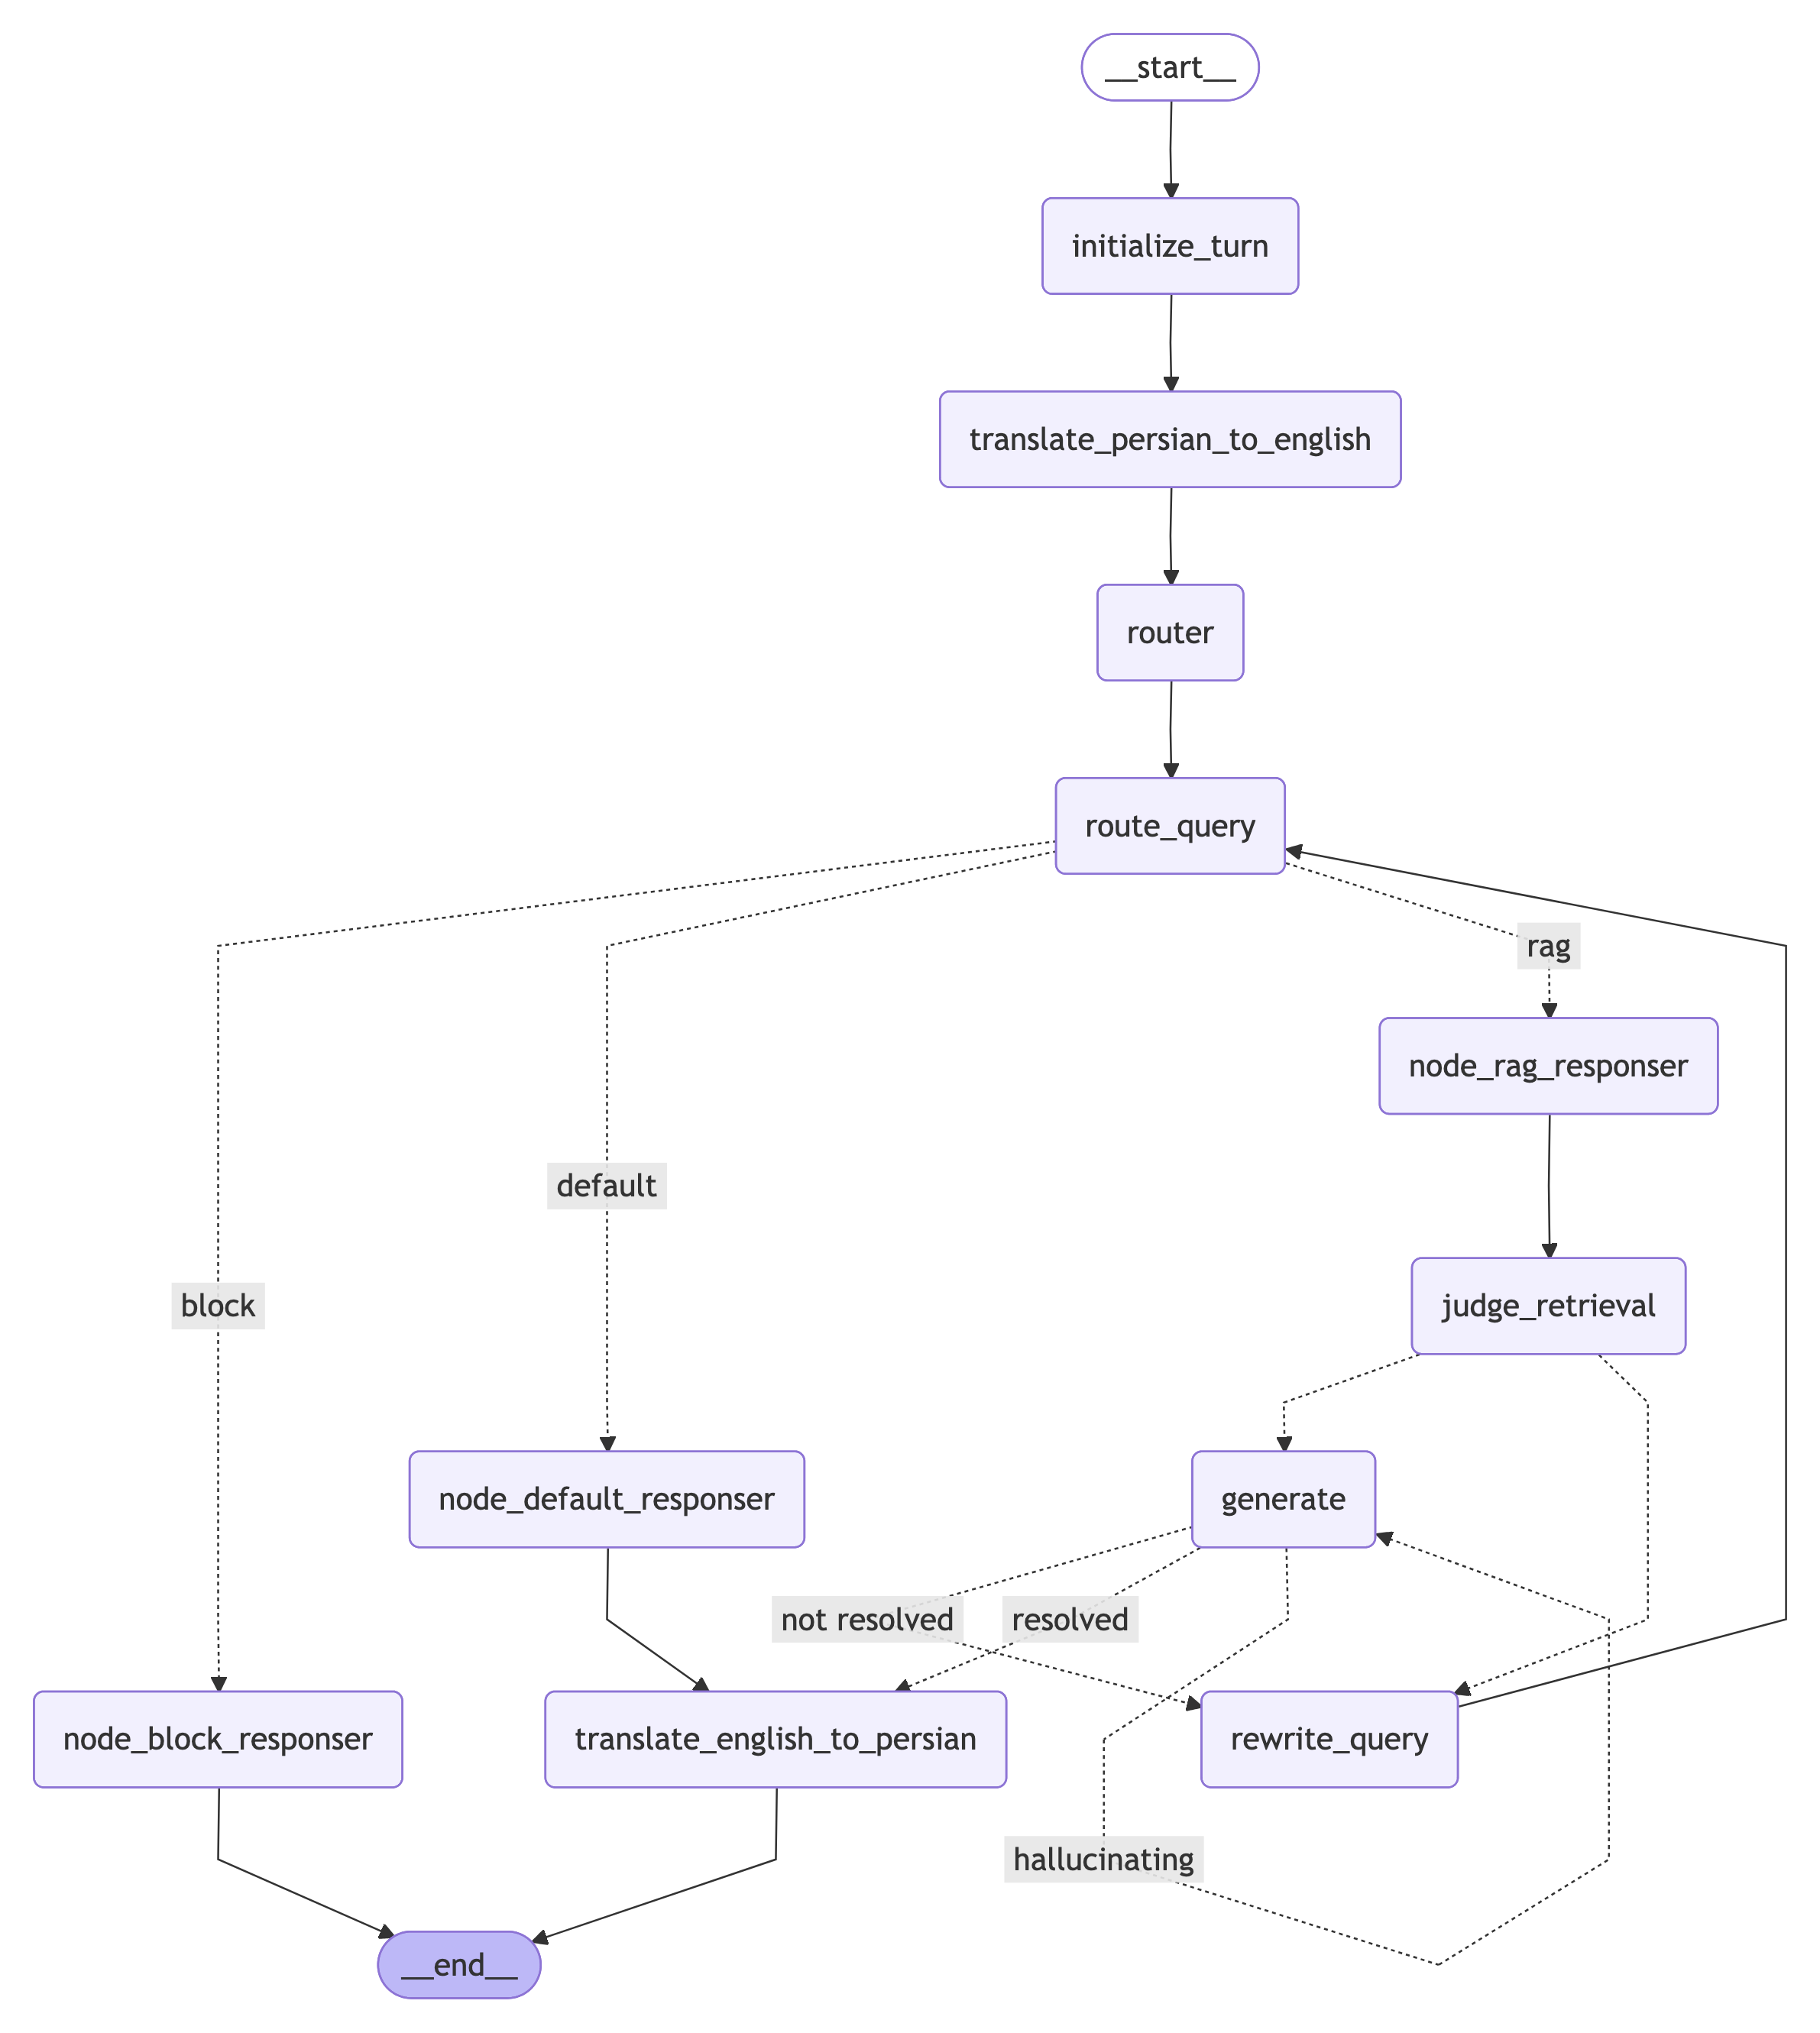

'diagram = Image(\n    graph.get_graph().draw_mermaid_png()\n)\ndisplay(diagram)'

In [11]:
#----7. 그래프 생성 및 컴파일----
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod
import nest_asyncio

nest_asyncio.apply()

memory = MemorySaver()

graph = (
    StateGraph(State)
    .add_node("initialize_turn", initialize_turn)
    .add_node("translate_persian_to_english", translate_persian_to_english)
    .add_node("router", router)
    .add_node("route_query", route_query)
    .add_node("node_rag_responser", node_rag_responser)
    .add_node("node_default_responser", node_default_responser)
    .add_node("node_block_responser", node_block_responser)
    .add_node("generate", generate)
    .add_node("judge_retrieval", judge_retrieval)
    .add_node("rewrite_query", rewrite_query)
    .add_node("translate_english_to_persian", translate_english_to_persian)
    .add_edge(START, "initialize_turn")
    .add_edge("initialize_turn", "translate_persian_to_english")
    .add_edge("translate_persian_to_english", "router")
    .add_edge("router", "route_query")
    .add_conditional_edges(
        "route_query",
        lambda state: state["route"],
        {
            "rag": "node_rag_responser",
            "default": "node_default_responser",
            "block": "node_block_responser",
        }
    )
    .add_edge("node_default_responser", "translate_english_to_persian")
    .add_edge("node_rag_responser", "judge_retrieval")
    .add_conditional_edges(
        "judge_retrieval",
        generate_or_rewrite_query,
        {
            "generate": "generate",
            "rewrite_query": "rewrite_query"
        }
    )
    .add_edge("rewrite_query", "route_query")
    .add_conditional_edges(
        "generate",
        judge_factfullness,
        {
            "hallucinating": "generate",
            "resolved": "translate_english_to_persian",
            "not resolved": "rewrite_query"
        }
    )
    .add_edge("translate_english_to_persian", END)
    .add_edge("node_block_responser", END)
    .compile(checkpointer=memory)
)


#그래프 시각화
from IPython.display import display, Image

diagram = Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER))
display(diagram)

"""diagram = Image(
    graph.get_graph().draw_mermaid_png()
)
display(diagram)"""

In [12]:
#----8. Test ----
import uuid
from langgraph.errors import GraphRecursionError

def run(input_msg: str, session_id: str):
    """
    지정된 세션 ID로 대화를 실행하고, Checkpointer(memory)를 사용해 대화 기록을 이어갑니다.
    실행이 완료되거나 오류 발생 시, 누적된 전체 로그를 DB/JSON에 저장합니다.
    """
    def clean(text):
        return text.replace("\\n", "")[:50] + "..."
    
    # LangGraph 실행 설정 (세션 ID = thread_id)
    config = RunnableConfig(
        configurable={"thread_id": session_id},
        recursion_limit=20
    )

    # 1. Checkpointer에서 현재 세션 상태 가져오기 (이전 턴 횟수 확인용)
    try:
        current_checkpoint = graph.get_state(config)
        current_state_values = current_checkpoint.values if current_checkpoint else {}
    except Exception as e:
        logger.warning(f"Checkpointer에서 상태 로드 실패 (세션: {session_id}): {e}. 새 세션으로 시작합니다.")
        current_state_values = {}

    conversation_count = current_state_values.get("conversation_count", 0)
    print(f"--- Running Session: {session_id} (Turn: {conversation_count + 1}) ---")
    
    # 2. 이번 턴의 입력값 설정
    inputs = {
        "input_msg": input_msg,
        "session_id": session_id,
    }
    
    final_stream_output = {} # 스트리밍의 마지막 출력을 저장하기 위함

    try:    
        # 3. 그래프 실행 (스트리밍)
        for output in graph.stream(inputs, config):
            for key, value in output.items():
                final_stream_output.update(value) # 최종 응답을 위해 스트림의 마지막 값을 저장
                
                # (기존의 스트리밍 출력 로직)
                if "input_msg" in value:
                    print(f"     input_msg    : {value['input_msg']}")
                if "documents" in value and value['documents']:
                    for idx, doc in enumerate(value['documents']):
                        print(f"     document    : {clean(doc.page_content)}")
                if "generation" in value and value['generation']:
                    print(f"     generation     : {value['generation']}")
                if "initial_translated" in value and value['initial_translated']:
                    print(f"     initial_translated : {value['initial_translated']}")
                if "source" in value and value['source']:
                    print(f"     source     : {value['source']}")
                if "route" in value and value['route']:
                    print(f"     route      : {value['route']}")
                # (출력 로직 끝)

        # 4. (성공 시) 실행 완료 후, checkpointer에서 최종 상태를 가져와서 저장
        final_checkpoint = graph.get_state(config)
        if final_checkpoint:
            save_final_logs(final_checkpoint.values)
        else:
            logger.error(f"성공 후 Checkpoint를 가져오는 데 실패했습니다. (Session: {session_id})")

        print("\n")
        print("Generation: ", final_stream_output.get("final_translated", final_stream_output.get("generation", "")))
        print("="*100, "\n")
        
        return { 
                "generation": final_stream_output.get("generation", ""),
                "final_translated": final_stream_output.get("final_translated", "")
        }
    
    except (Exception, GraphRecursionError) as e:
        print(f"\n[ERROR] An unexpected error occurred: {e}")
        # logger.error 대신 logger.critical 사용 (심각한 오류) 및 .txt 파일에 기록
        logger.critical(f"Graph execution failed for session {session_id}: {e}", exc_info=True)
        
        # 5. (실패 시) 오류 발생 시, checkpointer에서 마지막으로 성공한 상태를 가져와서 저장
        try:
            last_good_checkpoint = graph.get_state(config)
            if last_good_checkpoint and last_good_checkpoint.values.get("log_steps"):
                print(f"Attempting to save logs up to the point of failure (Session: {session_id})...")
                # Checkpointer는 마지막 '완료된' 스텝의 상태를 가지고 있으므로,
                # 해당 스텝까지의 누적된 log_steps가 저장됩니다.
                save_final_logs(last_good_checkpoint.values)
            else:
                 logger.warning(f"오류 발생 후 Checkpoint를 가져올 수 없거나 로그가 없습니다. (Session: {session_id})")
        except Exception as log_e:
            print(f"\n[CRITICAL ERROR] Failed to save logs after graph failure: {log_e}")
            logger.critical(f"Failed to save logs after graph failure (Session: {session_id})", exc_info=True)
        
        # 오류가 발생했을 때 반환할 값
        return {"generation": None, "final_translated": "An error occurred."}

In [13]:
#----9. Main 실행 블록----
if __name__ == "__main__":
    inputs = [
        ['Hello, I have a question about your religion. I hope you can answer me.', 'Before knowing Jesus Christ, I lived in darkness; without hope, without peace, and without a true understanding of God. But when I heard the message of His love, forgiveness, and salvation, my heart was changed.']
    ]
    
    for session in inputs:
        session_id = str(uuid.uuid4())
        print(f"--- Starting New Session: {session_id} ---")
        for msg in session:
            run(msg, session_id)
        print(f"--- Finished Session: {session_id} ---\n")

--- Starting New Session: e0fb5a34-34a8-4018-99d0-ede4228f34f9 ---
--- Running Session: e0fb5a34-34a8-4018-99d0-ede4228f34f9 (Turn: 1) ---
>> INITIALIZE TURN: Clearing state for new input.
   State cleared. Documents list is now empty.
     input_msg    : Hello, I have a question about your religion. I hope you can answer me.
>> TRANSLATE PERSIAN TO ENGLISH


2025-11-04 17:07:34,218 - __main__ - CRITICAL - Graph execution failed for session e0fb5a34-34a8-4018-99d0-ede4228f34f9: Error code: 401 - {'error': {'message': 'Your API key is invalid. Please verify your API key or generate a new one from our API keys management page (https://console.upstage.ai/api-keys). Remember to keep your API keys secure and never share them publicly', 'type': 'invalid_request_error', 'param': '', 'code': 'invalid_api_key'}}
Traceback (most recent call last):
  File "/var/folders/8g/wzmcdrdd4j926_9xm67xm3mc0000gn/T/ipykernel_45464/447285857.py", line 40, in run
    for output in graph.stream(inputs, config):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/langgraph/pregel/__init__.py", line 2534, in stream
    for _ in runner.tick(
  File "/var/folders/8g/wzmcdrdd4j926_9xm67xm3mc0000gn/T/ipykernel_45464/3679992453.py", line 17, in translate_persian_to_english
    translated_msg = chain.invoke({"input_msg": input_msg})
    


[ERROR] An unexpected error occurred: Error code: 401 - {'error': {'message': 'Your API key is invalid. Please verify your API key or generate a new one from our API keys management page (https://console.upstage.ai/api-keys). Remember to keep your API keys secure and never share them publicly', 'type': 'invalid_request_error', 'param': '', 'code': 'invalid_api_key'}}
--- Running Session: e0fb5a34-34a8-4018-99d0-ede4228f34f9 (Turn: 1) ---
>> INITIALIZE TURN: Clearing state for new input.
   State cleared. Documents list is now empty.
     input_msg    : Before knowing Jesus Christ, I lived in darkness; without hope, without peace, and without a true understanding of God. But when I heard the message of His love, forgiveness, and salvation, my heart was changed.
>> TRANSLATE PERSIAN TO ENGLISH

[ERROR] An unexpected error occurred: Error code: 401 - {'error': {'message': 'Your API key is invalid. Please verify your API key or generate a new one from our API keys management page (https:/

In [ ]:
#----9. Main 실행 블록---- 세션 이동 확인
if __name__ == "__main__":
    inputs = [
        ["오늘 날씨는 어때?", "یک رستوران پیشنهاد دهید", "Can I get money? I need Scholarship.", "Can I get more information?", "너는 누구야?"],
        ["How can I get the Visa?", "Can I get more information?", "The only God is Alla", "What is Christianity"]
    ]
    
    for session in inputs:
        session_id = str(uuid.uuid4())
        print(f"--- Starting New Session: {session_id} ---")
        for msg in session:
            run(msg, session_id)
        print(f"--- Finished Session: {session_id} ---\n")

--- Starting New Session: 05962f85-0ce7-46bf-857f-57162ff6b201 ---
>> INITIALIZE TURN: Clearing state for new input.
   State cleared. Documents list is now empty.
     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : 
     source     : 
     route      : 
>> TRANSLATE PERSIAN TO ENGLISH


2025-10-31 22:40:45,889 - httpx - INFO - HTTP Request: POST https://api.upstage.ai/v1/solar/chat/completions "HTTP/1.1 200 OK"


     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : How is the weather today?
     source     : 
     route      : 
     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : How is the weather today?
     source     : 
     route      : 


2025-10-31 22:40:46,565 - httpx - INFO - HTTP Request: POST https://api.upstage.ai/v1/solar/chat/completions "HTTP/1.1 200 OK"


>> ROUTE QUESTION TO DEFAULT
     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : How is the weather today?
     source     : 
     route      : default
>> DEFAULT


...

     input_msg    : What is Christianity
     generation     : 
     initial_translated : Christianity is a monotheistic Abrahamic religion based on the life and teachings of Jesus Christ as presented in the New Testament. It is the world's largest religion, with approximately 2.4 billion followers, or about one-third of the global population, known as Christians. Christianity developed out of Second Temple Judaism in the 1st century CE, following the teachings of Jesus of Nazareth, whom Christians believe to be the Son of God and the awaited Messiah (Christ) prophesied in the Hebrew Scriptures.  

The religion emphasizes core beliefs such as the Trinity (God as Father, Son, and Holy Spirit), the resurrection of Jesus, salvation through faith, and the authority of the Bible as sacred scripture. Major branches include the Catholic Church, the Orthodox Church, and various Protestant denominations, each with distinct traditions, doctrines, and practices. Central practices include worship 

2025-10-31 22:41:39,011 - httpx - INFO - HTTP Request: POST https://api.upstage.ai/v1/solar/chat/completions "HTTP/1.1 200 OK"


>> ROUTE QUESTION TO DEFAULT
     input_msg    : What is Christianity
     generation     : 
     initial_translated : Christianity is a monotheistic Abrahamic religion based on the life and teachings of Jesus Christ as presented in the New Testament. It is the world's largest religion, with approximately 2.4 billion followers, or about one-third of the global population, known as Christians. Christianity developed out of Second Temple Judaism in the 1st century CE, following the teachings of Jesus of Nazareth, whom Christians believe to be the Son of God and the awaited Messiah (Christ) prophesied in the Hebrew Scriptures.  

The religion emphasizes core beliefs such as the Trinity (God as Father, Son, and Holy Spirit), the resurrection of Jesus, salvation through faith, and the authority of the Bible as sacred scripture. Major branches include the Catholic Church, the Orthodox Church, and various Protestant denominations, each with distinct traditions, doctrines, and practices. Centr

2025-10-31 22:41:40,199 - httpx - INFO - HTTP Request: POST https://api.upstage.ai/v1/solar/chat/completions "HTTP/1.1 200 OK"


     input_msg    : What is Christianity
     generation     : \n\nI appreciate our chat! If you have questions about faith or spirituality, I'm here to help.
     initial_translated : Christianity is a monotheistic Abrahamic religion based on the life and teachings of Jesus Christ as presented in the New Testament. It is the world's largest religion, with approximately 2.4 billion followers, or about one-third of the global population, known as Christians. Christianity developed out of Second Temple Judaism in the 1st century CE, following the teachings of Jesus of Nazareth, whom Christians believe to be the Son of God and the awaited Messiah (Christ) prophesied in the Hebrew Scriptures.  

The religion emphasizes core beliefs such as the Trinity (God as Father, Son, and Holy Spirit), the resurrection of Jesus, salvation through faith, and the authority of the Bible as sacred scripture. Major branches include the Catholic Church, the Orthodox Church, and various Protestant denominatio

In [ ]:
#----9. Main 실행 블록---- 첫 질문 입력
if __name__ == "__main__":
    inputs = [
    'Hello, can I get more info on this?', 'Hello, how are you?', 'Hello, my dear friend, how are you?', 'Who are you?', 'What is your message', 'what is your truth?', 'How to obtain a cash assistance of 10,000 Afghanis for all of Afghanistan on Independence Day?', 'How to get the JazzCash Rs3000 user bonus?', 'I want to learn.', 'I want to enroll in your English course.',
    'I believe in Jesus Christ, who is the messenger of Almighty God; there is no need.',       'Hello, I am a follower of guidance.', 'Hello, I would like to receive the Holy Bible.', 'In reality, the Bible is my obsession; it has drawn me towards itself. I love and believe in Jesus Christ with all my heart and soul.',        'Christ ascended to heaven to send the Holy Spirit from the Father for us.', 'I want to marry a Christian girl, is it possible?', 'I want to marry someone who is Christian.', 'I want to learn more about your business?', 'I need to read and understand the words of Jesus, and after that, the meeting will be better and more beneficial.', 'What is the name of the church that I am in?', 'What is your opinion about this verse? Are you ready to open your heart to the Lord?', 'What does this mean?', 'What should I read?', 'What is the name of this movie?',
    'I need your guidance and cooperation.', 'Could you please provide more context or specify what you need information about?', 'Could you send me porn sex videos? What is it, where are you? Please provide details.', 'Can you help me? I also have a desire to be a follower of Jesus Christ as long as I live and to serve in the church my whole life.', 'Please provide the text you would like to have translated from Pashto to English.', 'Please tell me your exact address in Kabul.', 'Please provide more context or details about what you need information on.', 'Please let me know the time of your meeting; I would like to attend.', 'Please provide more context or clarify?', 'Can I learn more about your business?', 'Can I get to know you, beautiful girl? Can I have some information?',
    'Free 50GB birthday data is available for all network users in celebration of the anniversary.', "Happy Independence Day of Afghanistan! Atoma is giving 50 GB of free data to its customers in celebration of Afghanistan's Independence Day in 2025.", "The Islamic Emirate of Afghanistan is providing a cash assistance of 85,000 Afghanis to Afghans on the occasion of Afghanistan's Independence Day.", 'The Mirwais Azizi Foundation is offering a support grant of 85,000 Afghanis for Afghans to promote business.','The Tak Educational Center proudly announces to fellow citizens residing in the city of Atak that it offers standardized training in English, Dari, French, Science, and Computer.', "Join us for Bible class and learn about God's word. May God bless you all.", 'Tonight we have a meeting at 9 PM Afghanistan time.', 'Follow the channel of the Encyclopedia of the Ten Readings on WhatsApp.', 'Follow the SABA RELAXING MASSAGE channel on WhatsApp.', 'Follow the AQ Brothers', 'clothing store channel on WhatsApp.',
    'Thank you for your message. We are currently unavailable, but we will respond to you as soon as possible.', 'Thank you, may Allah be with you, God willing.', 'Thank you, the world is grateful, dear brother.', 'Thank you for your kindness.', 'Thank you very much, respected teacher.', 'Thank you, brother. I sent you a message on Telegram.',
    'I am Muslim, thank God.','I am from Paktia province, Muhammad Khan.','I am in Afghanistan.','I live in Turkey, I am a refugee and I reside in the city of Nevşehir.','I have money.','I have a passport, please guide me.','I saw this on Facebook.','I just wanted to say that over the past year, I have endured a lot of hardships, but in return, I have learned many things.','I cannot read the line correctly.','I will destroy the church, God willing.','You have said something.','You have become Christian pigs.','You ate.'
]

    results = []

    for msg in inputs:
        session_id = str(uuid.uuid4())
        print(f"\n--- Running for Input: '{msg}' (Session: {session_id}) ---")
        outputs = run(msg, session_id)

        results.append({
            "Question": msg,
            "Generation (English)": outputs.get("generation", ""),
            "Final Translate (Persian)": outputs.get("final_translated", "")
        })
        print(f"--- Finished Session: {session_id} ---")

    # 데이터프레임 생성
    df = pd.DataFrame(results)

    # 전체 데이터프레임 출력
    print("\n\n" + "="*50)
    print("         >> 최종 결과: 입력 및 챗봇 답변 <<")
    print("="*50)
    # Pandas가 모든 텍스트를 보여주도록 설정
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', None)
    print(df)


hallucinating_question = ['Hello, I have a question about your religion. I hope you can answer me.', 'Before knowing Jesus Christ, I lived in darkness; without hope, without peace, and without a true understanding of God. But when I heard the message of His love, forgiveness, and salvation, my heart was changed.',]


--- Running for Input: 'Hello, can I get more info on this?' (Session: 84e9992a-dc83-4575-b2ef-b497bca16c90) ---
>> INITIALIZE TURN: Clearing state for new input.
   State cleared. Documents list is now empty.
     input_msg    : Hello, can I get more info on this?
     generation     : 
     initial_translated : 
     source     : 
     route      : 
>> TRANSLATE PERSIAN TO ENGLISH


2025-10-31 22:41:40,962 - httpx - INFO - HTTP Request: POST https://api.upstage.ai/v1/solar/chat/completions "HTTP/1.1 200 OK"


     input_msg    : Hello, can I get more info on this?
     generation     : 
     initial_translated : Hello, can I get more information about this?
     source     : 
     route      : 
     input_msg    : Hello, can I get more info on this?
     generation     : 
     initial_translated : Hello, can I get more information about this?
     source     : 
     route      : 


2025-10-31 22:41:41,417 - httpx - INFO - HTTP Request: POST https://api.upstage.ai/v1/solar/chat/completions "HTTP/1.1 200 OK"


>> ROUTE QUESTION TO DEFAULT
     input_msg    : Hello, can I get more info on this?
     generation     : 
     initial_translated : Hello, can I get more information about this?
     source     : 
     route      : default
>> DEFAULT


...

2025-10-31 22:41:47,621 - httpx - INFO - HTTP Request: POST https://api.upstage.ai/v1/solar/chat/completions "HTTP/1.1 200 OK"


     input_msg    : Hello, can I get more info on this?
     generation     : Hello! I’m here to offer support, hope, and encouragement from a Christian perspective. Whether you’re exploring faith, seeking comfort, or simply curious about how Jesus’ love can bring healing and purpose to life’s challenges, I’m here to listen and share gently.  

Could you share a bit more about what you’re looking for? For example:  
- Are you facing a difficult situation and wondering how faith might help?  
- Do you have questions about Christianity or the Bible?  
- Are you seeking spiritual growth or peace?  

If your question isn’t faith-related, I’ll kindly ask that we focus on topics where I can offer biblically grounded support. Thank you for understanding!  

*With warmth and prayer,*  
[Your Name] (as a Christian counselor AI)
     initial_translated : Hello, can I get more information about this?
     source     : 
     route      : default


Generation:  سلام! من اینجا هستم تا از دیدگاه مسیح

2025-10-31 22:41:47,982 - httpx - INFO - HTTP Request: POST https://api.upstage.ai/v1/solar/chat/completions "HTTP/1.1 200 OK"


     input_msg    : Hello, how are you?
     generation     : 
     initial_translated : Hello, how are you?
     source     : 
     route      : 
     input_msg    : Hello, how are you?
     generation     : 
     initial_translated : Hello, how are you?
     source     : 
     route      : 


KeyboardInterrupt: 